<a href="https://colab.research.google.com/github/sashapisterman/DSO510-Business-Analytics/blob/main/Assignment3/DSO_510_Assignment_3_Pisterman_Sasha_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Assignment: Business Analytics

In this assignment, you will practice building and evaluating a linear regression model using the Diabetes dataset from `sklearn`. Follow the notebook step by step and answer the questions along the way. Make sure your code is well-commented and your answers are clearly written.

# Data Dictionary

The load_diabetes dataset from scikit-learn includes the following ten independent variables:

- age: age in years
- sex: gender of the patient
- bmi: body mass index
- bp: average blood pressure
- s1: tc, total serum cholesterol
- s2: ldl, low-density lipoproteins
- s3: hdl, high-density lipoproteins
- s4: tch, total cholesterol / HDL
- s5: ltg, possibly log of serum triglycerides level
- s6: glu, blood sugar level

These variables are used to predict the "target" variable, which is a quantitative measure of diabetes progression. In simpler terms, it's a numerical value that indicates how much the diabetes has progressed in a patient after a year, starting from when the initial measurements (the independent variables) were taken.

The goal of the linear regression model is to understand how the independent variables relate to and can predict this measure of disease progression.

## Step 1: Load Required Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Load the Dataset

In [26]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

**Questions:**
1. What are the features (independent variables) in this dataset?

The features in the dataset are the 10 independent variables listed in the data dictionary. They are a set of data for a diabetes patient.

2. What is the target variable?

The target variable is a quantitative measure of diabetes progression in each patient after a year.

## Step 3: Explore the Data (EDA)

In [27]:
# Display the first 5 rows of X to preview the feature data and confirm it loaded correctly
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [28]:
# Generate summary statistics for both features and target;
# features are pre-standardized (mean ≈ 0) while the target remains in its original units
df = X.copy()
df['target'] = y
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [29]:
# Check each column for missing values; none found, so no imputation or row removal is needed
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


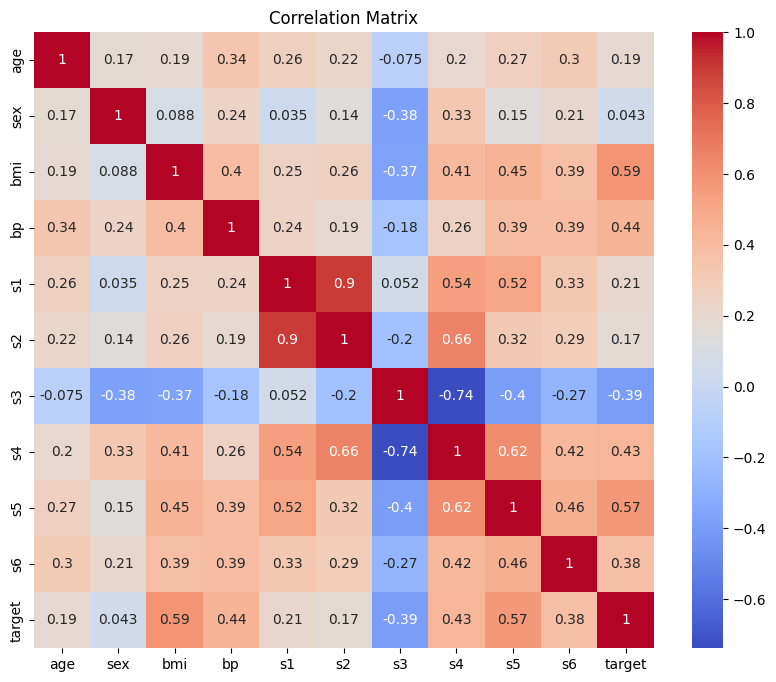

In [30]:
# Visualize correlations between all features and the target;
# BMI (0.59) and s5 (0.57) show the strongest ties to the target,
# while s1/s2 (0.90) and s3/s4 (-0.74) reveal multicollinearity among the features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

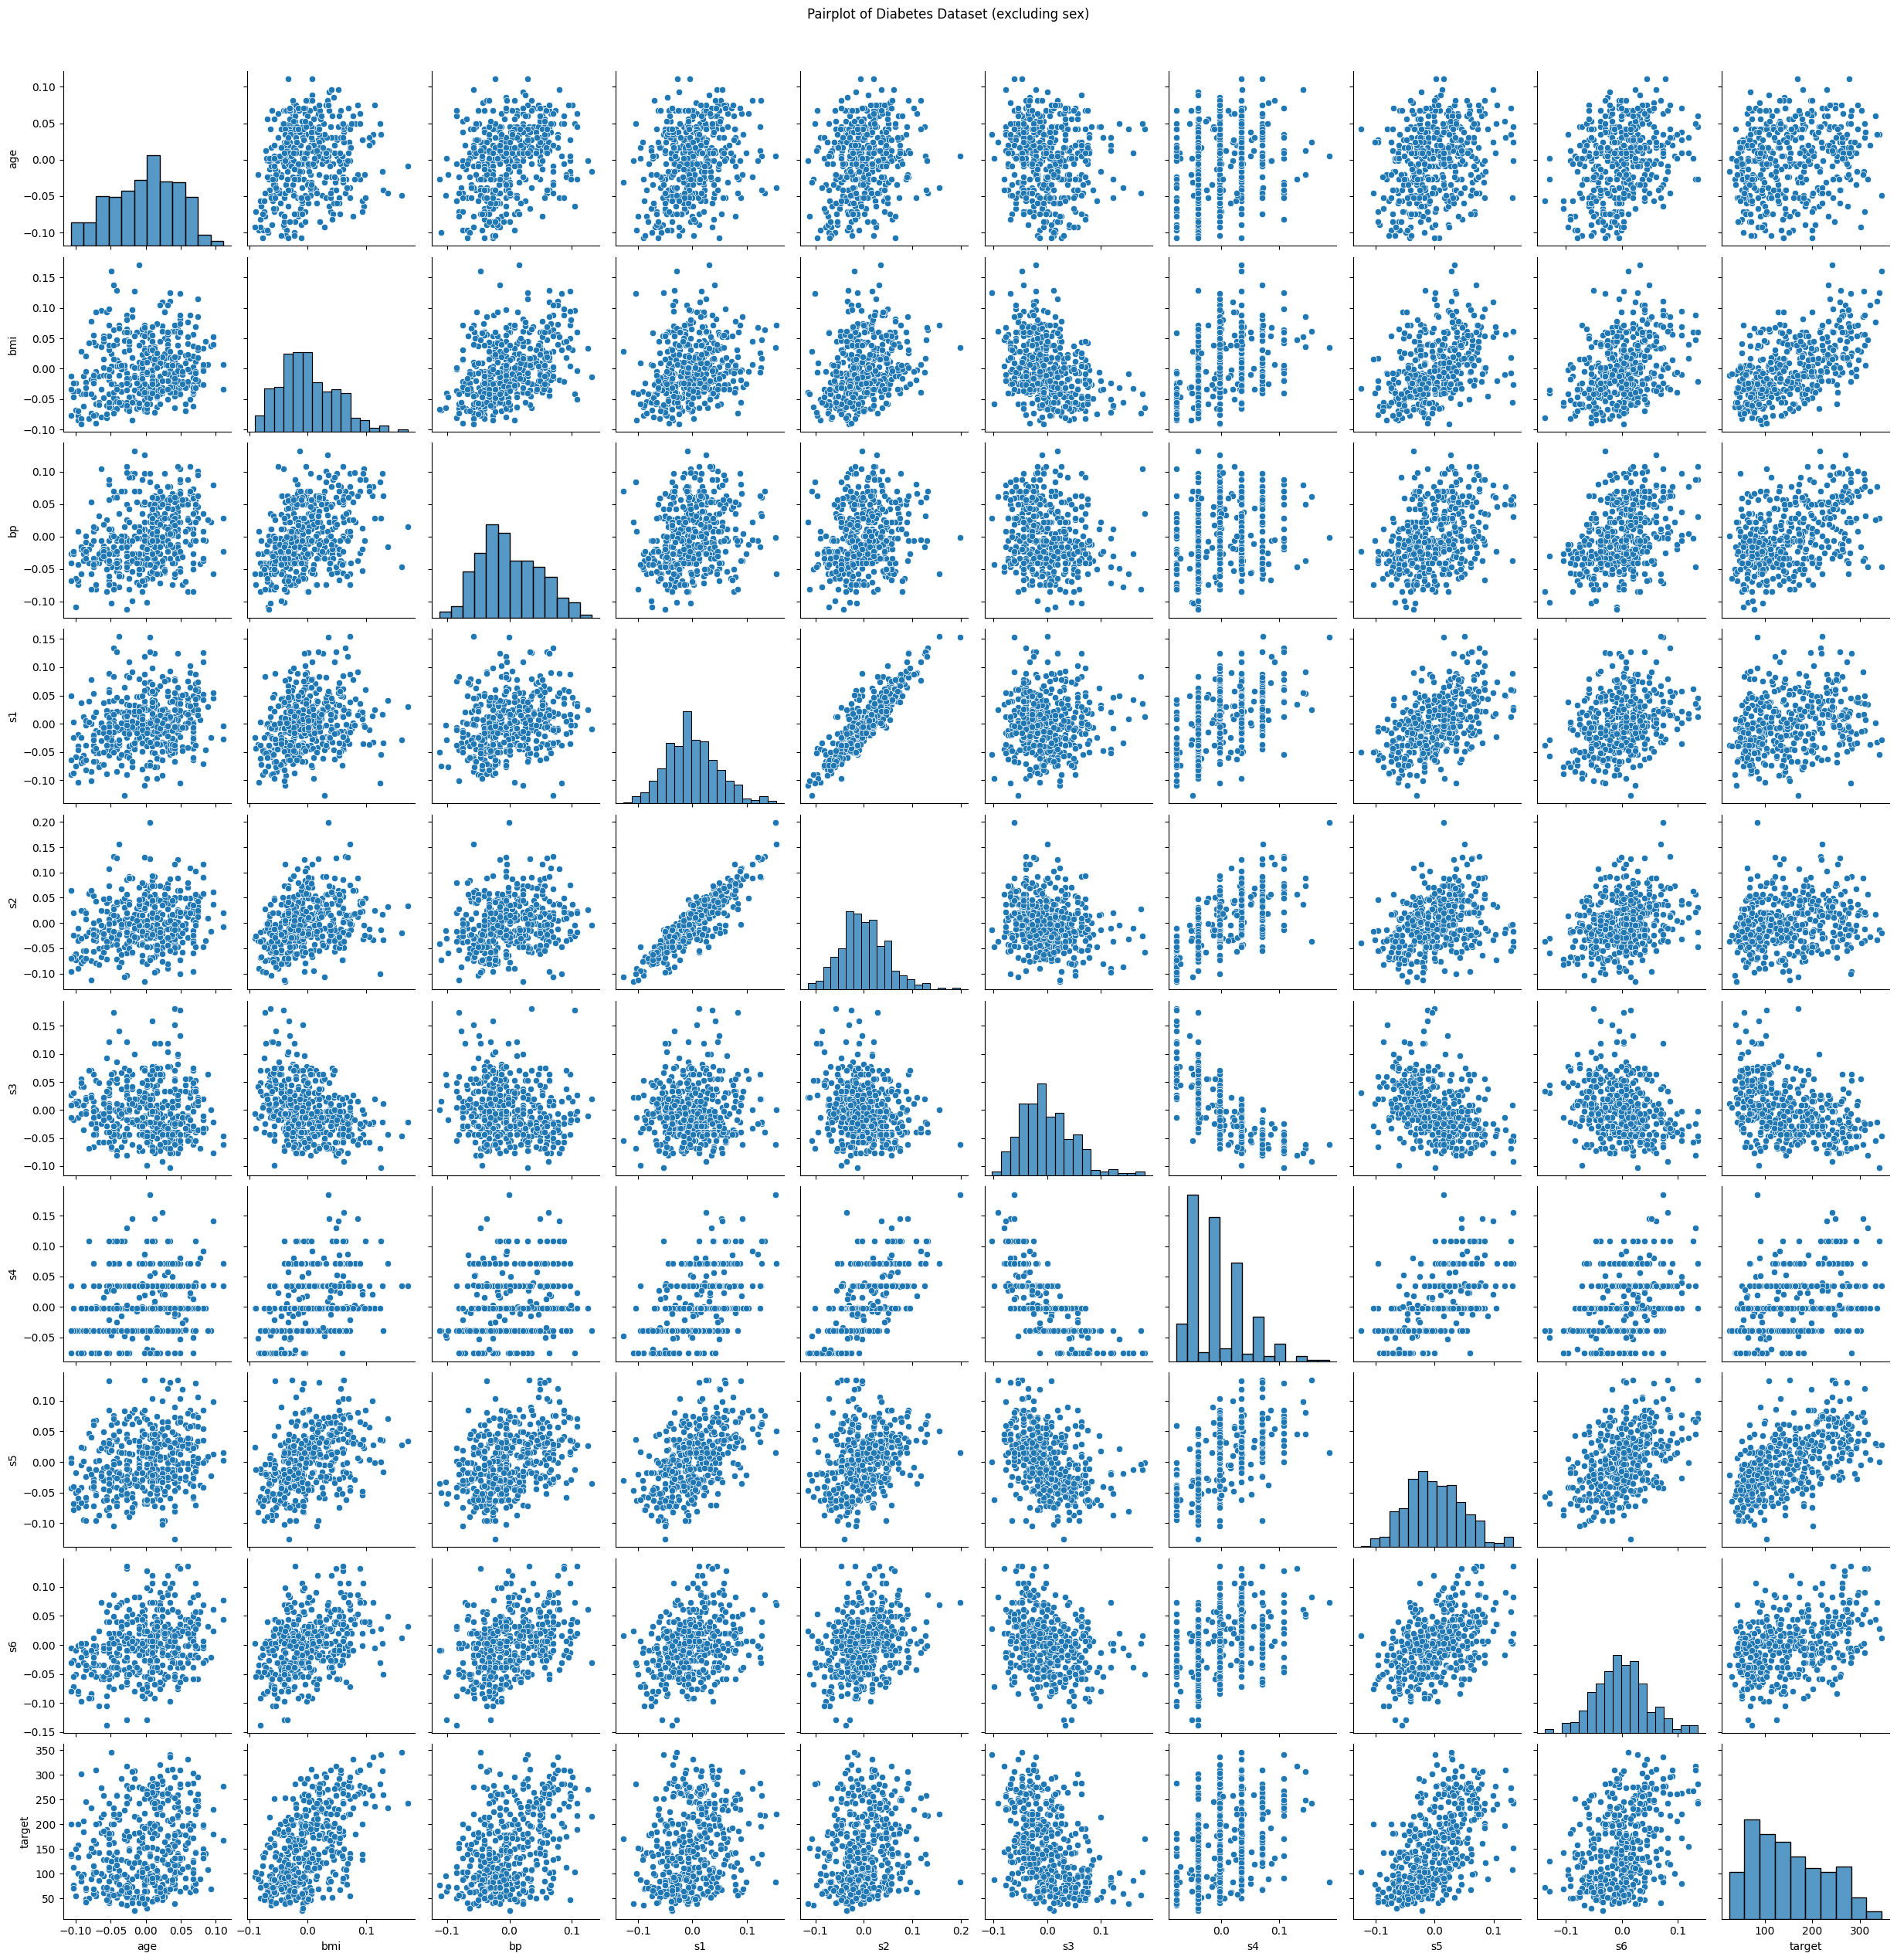

In [31]:
# Visualize pairwise relationships across features and target;
# bmi and s5 show the clearest positive trends with the target,
# s1/s2 and s3/s4 show tight linear patterns (confirming multicollinearity),
# and s4's distribution looks unusual — clustered into discrete bands rather than smooth
sns.pairplot(df.drop('sex', axis=1))
plt.suptitle("Pairplot of Diabetes Dataset (excluding sex)",y=1.02)
plt.show()

**EDA Questions:**
1. Are there any missing values in the dataset? If yes, how would you handle them?

There are no missing values in the dataset.

2. Which feature has the strongest correlation with the target variable?

BMI has the strongest correlation with the target (0.59), followed closely by s5 (0.57), suggesting body mass index is one of the most informative predictors of diabetes progression.

3. Do any features seem to be highly correlated with each other?

Yes, s1 and s2 are highly correlated (0.90), and s3 and s4 show a strong negative correlation (-0.74). This multicollinearity means those pairs carry overlapping information, which could affect how reliably the model estimates their individual coefficients.

4. What do the pairplots suggest about the relationships between some key features and the target?

The pairplots show that BMI and s5 have the clearest positive relationships with the target; as those values increase, diabetes progression tends to increase too. Most other features show a weak, scattered relationship with the target.

5. Based on the statistics and plots, do you see any potential outliers or skewed distributions?

The target variable is right-skewed: most patients cluster at lower progression scores, with a smaller number of patients extending out to much higher scores. I don't see obvious extreme outliers, just a long tail.

6. Which feature(s) might you consider dropping or transforming before modeling? Why?

I'd consider dropping or transforming one feature from each highly-correlated pair (s1/s2, and s3/s4) to reduce multicollinearity. I'd also look more closely at s4, since its distribution looks unusual, clustered into a few bands rather than smoothly spread out, which might mean it needs transforming before modeling.

7. Are there any features that seem to have a non-linear relationship with the target?

Most relationships in the pairplot look roughly linear (loose, diffuse clouds) rather than curved; I don't see any obvious U-shaped or exponential patterns. Linear regression seems like a reasonable model choice here.

## Step 4: Split the Data

In [32]:
# Split the data into 80% training and 20% testing sets, using a fixed random_state
# so the split is reproducible; ensures we can evaluate the model on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Question:**
1. Why do we split the data into training and test sets?

We split the data into training and test sets so we can evaluate the model on data it has never seen before. If we trained and tested on the same data, the model could fit closely to oddities in that specific dataset and appear to perform well, without that meaning it would generalize to new patients. The test set acts as a stand-in for new, unseen data.

## Step 5: Build the Linear Regression Model

In [33]:
# Initialize and train a linear regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
# Extract the model's coefficients and sort them to see which features have the largest effect;
# note: s1 and s2 show extreme, opposite-signed coefficients due to their high multicollinearity (0.90),
# so their individual values shouldn't be taken at face value
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients.sort_values(ascending=False))

s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
s3     163.419983
s6      48.670657
age     37.904021
sex   -241.964362
s1    -931.488846
dtype: float64


**Questions:**
1. What are the coefficients of the model?

The model's coefficients, from largest to smallest, are: s5 (736.20), bmi (542.43), s2 (518.06), bp (347.70), s4 (275.32), s3 (163.42), s6 (48.67), age (37.90), sex (-241.96), and s1 (-931.49).

2. What does each coefficient tell you about the relationship between that feature and the target variable?

Each coefficient represents the change in predicted diabetes progression for a one-unit increase in that feature, holding all other features constant. Positive coefficients (like s5, bmi, and s2) mean higher values of that feature are associated with more predicted progression; negative coefficients (like sex and s1) mean the opposite. However, s1 and s2's coefficients should be interpreted with caution — because they're highly correlated with each other (0.90), the model has trouble isolating their individual effects, which produces the unusually large, opposite-signed coefficients for s1 and s2 even though neither showed a strong correlation with the target on its own in the EDA. This is a sign of multicollinearity distorting the individual coefficient estimates.

## Step 6: Evaluate the Model

In [35]:
# Generate predictions on the test set and evaluate model performance using MSE and R²
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 2900.193628493482
R-squared: 0.4526027629719195


**Questions:**
1. What is the R-squared value, and how do you interpret it in this context?

The R-squared value is approximately 0.45, meaning the model explains about 45% of the variation in diabetes progression scores using these features. The remaining 55% is driven by factors not captured in this dataset.

2. What does the Mean Squared Error tell you about the model’s performance?

The Mean Squared Error (≈2900) represents the average squared difference between predicted and actual progression scores. Because it's squared, it's hard to interpret directly in original units, but taking its square root (≈54) gives a rough sense that predictions are typically off by about 54 points on the progression scale.

3. Is this a good model? Why or why not?

It's a moderate model, not a strong one. Explaining 45% of the variance is meaningfully better than guessing, but more than half of what drives diabetes progression isn't captured here — so it's useful as a starting point or for understanding general trends, but not reliable enough for precise, individual-level predictions.

4. What are some potential limitations of using linear regression in this case?

Linear regression assumes the relationships between features and the target are linear and additive, which may not fully hold here. It's also sensitive to multicollinearity, which we already saw distort the s1/s2 coefficients, and it can't capture interactions between features (e.g., the combined effect of bmi and blood pressure together) unless those interactions are explicitly added.

## Step 7: Optional Challenge

Try improving your model:
- Standardize or normalize the features
- Remove multicollinear variables

In [36]:
# Drop s2 and s3 to address multicollinearity with s1 and s4 respectively;
# kept whichever feature in each pair had the stronger individual correlation with the target
X_train_reduced = X_train.drop(columns=['s2', 's3'])
X_test_reduced = X_test.drop(columns=['s2', 's3'])

model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train)

coefficients_reduced = pd.Series(model_reduced.coef_, index=X_train_reduced.columns)
print(coefficients_reduced.sort_values(ascending=False))

y_pred_reduced = model_reduced.predict(X_test_reduced)
mse_reduced = mean_squared_error(y_test, y_pred_reduced)
r2_reduced = r2_score(y_test, y_pred_reduced)
print("Reduced Model MSE:", mse_reduced)
print("Reduced Model R-squared:", r2_reduced)

bmi    560.068377
s5     497.381061
bp     345.491636
s4     323.468556
s6      53.489755
age     43.467177
sex   -239.141539
s1    -370.067117
dtype: float64
Reduced Model MSE: 2915.131193954514
Reduced Model R-squared: 0.4497833711971907


**Bonus Questions:**
1. How did your changes affect model performance?

Removing s2 and s3 barely changed performance — R² went from 0.453 to 0.450 and MSE rose only slightly (2900 to 2915). However, s1's coefficient dropped from an extreme -931 to a much more reasonable -370, making it far more trustworthy and interpretable, even though predictive accuracy stayed essentially the same.

2. What would be your next steps to improve this model further?

Next steps could include trying regularized regression (Ridge or Lasso), which handles multicollinearity automatically instead of requiring manual feature removal, or exploring non-linear models (like random forests) to see if they capture more of the unexplained variance, since linear regression only explained 45% here.

##AI Use Disclosure

I used Claude (Anthropic) throughout this assignment as both a learning aid and a drafting tool. For the early sections (data loading, EDA interpretation, and the train/test split rationale), I used Claude conversationally to understand concepts I hadn't yet learned — for example, asking it to explain how to read a correlation heatmap and pairplot, why the model assigned an extreme, unstable coefficient to a highly correlated feature (s1), and why models are evaluated on held-out test data rather than training data. I drafted my own answers and asked Claude to review and refine them. All code was executed in my own Colab environment; all reported coefficients, R², and MSE values reflect my actual model output, not generated or invented numbers. Representative prompts I used included: "explain why we split data into training and test sets," "why does s1 have such an extreme coefficient," and "write the Step 6 evaluation answers based on my R² and MSE output."